# CodeSearchNet Dataset Exploration — Code Copilot (RAG + LoRA + Agent)

This notebook explores **CodeSearchNet (Python subset)** as the dataset for a new,
from-scratch experiment, for the purpose of planning the preprocessing stage of the project.

**What this notebook checks:**
1. Loading the dataset and its size
2. Structure of a single record (available fields)
3. Length statistics (code / docstring) — charts
4. Distribution by repository — charts
5. Documentation quality/noise (empty docstrings, too-short docstrings, etc.)
6. Token-level length check (real tokenizer, not just chars/words)
7. Documentation language check (is it actually English?)
8. Near-duplicate code check on the full dataset (not just the sample)
9. Manual spot-check of "good by the stats" examples
10. Conclusions for planning the preprocessing (chunking, filtering, embeddings)

**Dataset:** [`claudios/code_search_net`](https://huggingface.co/datasets/claudios/code_search_net)
— an unofficial reupload in parquet format of the original corpus (Husain et al., 2019),
which loads faster than the original version (which requires running a loading script).
There is also a fallback to the official version `code-search-net/code_search_net`
if the first one is unavailable.

> Recommended runtime: Colab, no GPU required for this exploration stage (CPU is enough).


## Step 0: Installation and loading

In [1]:
!pip install -q datasets pandas matplotlib pyarrow


In [2]:
from datasets import load_dataset
import pandas as pd

# First attempt: fast parquet reupload
try:
    ds = load_dataset("claudios/code_search_net", "python")
    source_used = "claudios/code_search_net (parquet reupload)"
except Exception as e:
    print("Failed to load claudios/code_search_net, falling back to the official version...")
    print(e)
    ds = load_dataset("code-search-net/code_search_net", "python", trust_remote_code=True)
    source_used = "code-search-net/code_search_net (official)"

print("Source actually loaded:", source_used)
print(ds)


README.md:   0%|          | 0.00/13.6k [00:00<?, ?B/s]

python/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  130MB            

python/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

python/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  135MB            

python/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

python/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

Source actually loaded: claudios/code_search_net (parquet reupload)
DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 23107
    })
})


## Step 1: Dataset size

Checking how many examples exist in each split (train/validation/test) — to plan how
much time/resources will be needed for the embedding and chunking stage.


In [3]:
sizes = {split: len(ds[split]) for split in ds.keys()}
sizes_df = pd.DataFrame(list(sizes.items()), columns=["split", "num_examples"])
sizes_df["percent"] = (sizes_df["num_examples"] / sizes_df["num_examples"].sum() * 100).round(1)
sizes_df


,split,num_examples,percent
0,train,412178,90.1
1,test,22176,4.8
2,validation,23107,5.1


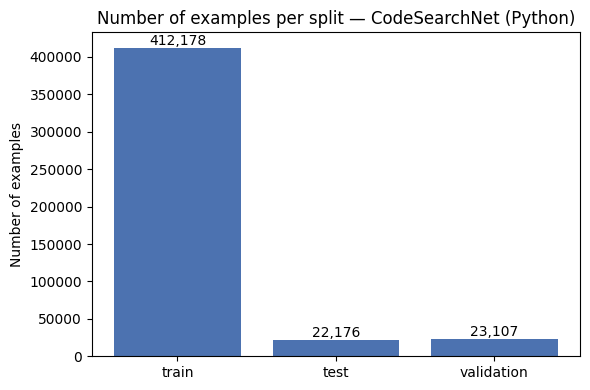

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sizes_df["split"], sizes_df["num_examples"], color="#4C72B0")
ax.set_title("Number of examples per split — CodeSearchNet (Python)")
ax.set_ylabel("Number of examples")
for i, v in enumerate(sizes_df["num_examples"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## Step 2: Structure of a single record

Checking which fields actually exist in a record, to know what's available for RAG
(code, documentation, file path, repository).


In [5]:
example = ds["train"][0]
for k, v in example.items():
    preview = str(v)
    if len(preview) > 200:
        preview = preview[:200] + " ...[truncated]"
    print(f"{k!r}:\n  {preview}\n")


'repository_name':
  proycon/pynlpl

'func_path_in_repository':
  pynlpl/formats/folia.py

'func_name':
  AbstractElement.addidsuffix

'whole_func_string':
  def addidsuffix(self, idsuffix, recursive = True):
        """Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked imp ...[truncated]

'language':
  python

'func_code_string':
  def addidsuffix(self, idsuffix, recursive = True):
        """Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked imp ...[truncated]

'func_documentation_string':
  Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked implicitly by :meth:`copy`

'func_code_url':
  https://github.com/proycon/pynlpl/blob/7707f69a91caaa6cde037f0d0379f1d42500a68b/pynlpl/formats/folia.py#L1263-L1271



## Step 3: Convert to a DataFrame for analysis (sample)

For a quick check, we take a sample (e.g. 20,000 rows from train) instead of the full
dataset — this is enough for statistical analysis and much faster than loading
everything into memory.


In [6]:
SAMPLE_SIZE = 20000
train_sample = ds["train"].shuffle(seed=42).select(range(min(SAMPLE_SIZE, len(ds["train"]))))
df = train_sample.to_pandas()

# Useful length columns for the analysis
code_col = "func_code_string" if "func_code_string" in df.columns else "whole_func_string"
doc_col = "func_documentation_string"
repo_col = "repository_name" if "repository_name" in df.columns else "repo"

df["code_len_chars"] = df[code_col].astype(str).str.len()
df["code_len_lines"] = df[code_col].astype(str).str.count("\n") + 1
df["doc_len_chars"] = df[doc_col].astype(str).str.len()
df["doc_len_words"] = df[doc_col].astype(str).str.split().str.len()

df[[code_col, doc_col, repo_col, "code_len_chars", "code_len_lines", "doc_len_chars", "doc_len_words"]].head()


,func_code_string,func_documentation_string,repository_name,code_len_chars,code_len_lines,doc_len_chars,doc_len_words
0,"def send_text_card(self, agent_id, user_ids, t...",文本卡片消息\n\n https://work.weixin.qq.com/a...,jxtech/wechatpy,1736,51,1181,74
1,"def get_group(self, name, user_name=None):\n ...",Get information on the given group or whether ...,jhuapl-boss/intern,686,19,489,63
2,"def dispatch(self, test=False): # pylint: dis...",Send configuration to satellites\n\n :r...,Alignak-monitoring/alignak,3655,106,55,6
3,"def cursor(self, status):\n """"""Turn und...",Turn underline cursor visibility on/off,PedalPi/Raspberry-Physical,225,4,39,5
4,"def is_contradictory(self, other):\n """"...",Can these two strings coexist ?,EventTeam/beliefs,537,16,31,6


## Step 4: Code length distribution (for chunking planning)

Function length determines a reasonable chunk size — embedding models are typically limited to 256-512 tokens, so this needs to be grounded in the actual distribution rather than assumed.


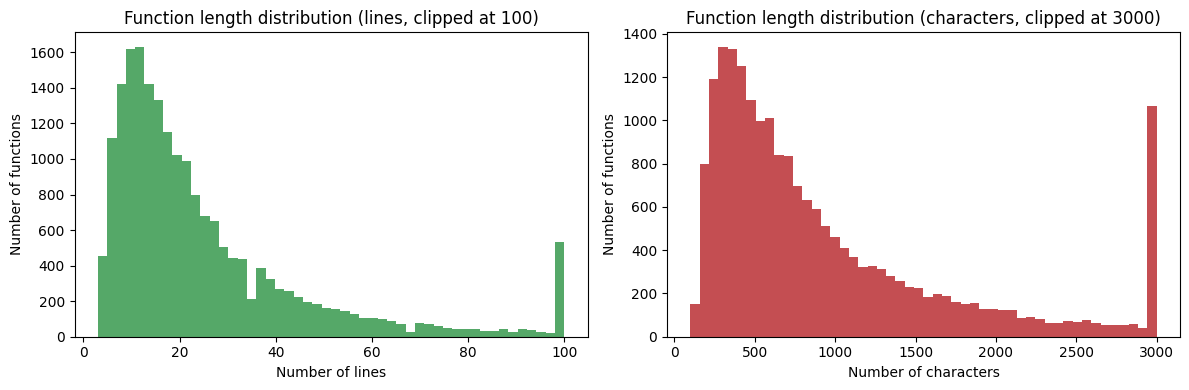

count    20000.000000
mean        26.911550
std         32.111868
min          3.000000
25%         11.000000
50%         18.000000
75%         31.000000
max        984.000000
Name: code_len_lines, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["code_len_lines"].clip(upper=100), bins=50, color="#55A868")
axes[0].set_title("Function length distribution (lines, clipped at 100)")
axes[0].set_xlabel("Number of lines")
axes[0].set_ylabel("Number of functions")

axes[1].hist(df["code_len_chars"].clip(upper=3000), bins=50, color="#C44E52")
axes[1].set_title("Function length distribution (characters, clipped at 3000)")
axes[1].set_xlabel("Number of characters")
axes[1].set_ylabel("Number of functions")

plt.tight_layout()
plt.show()

print(df["code_len_lines"].describe())


## Step 5: Documentation length distribution (for prompt/response planning for LoRA)

Docstrings that are too short (0-2 words) are usually not useful as an "answer" for
LoRA training — they should be filtered out.


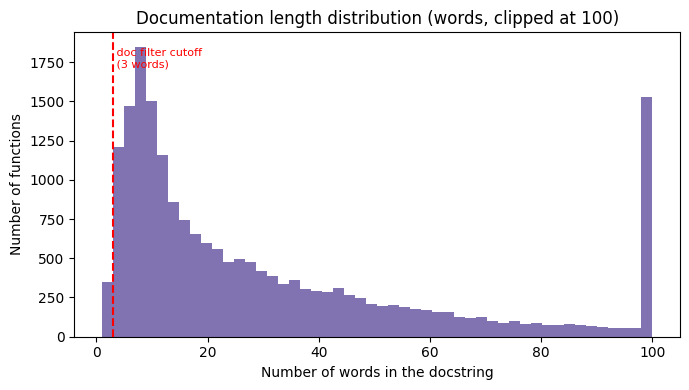

count    20000.000000
mean        37.464250
std         59.121104
min          1.000000
25%          9.000000
50%         19.000000
75%         44.000000
max       1365.000000
Name: doc_len_words, dtype: float64

Docstrings at or below the 3-word filter cutoff: 919 out of 20,000 (4.6%)


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["doc_len_words"].clip(upper=100), bins=50, color="#8172B2")
ax.set_title("Documentation length distribution (words, clipped at 100)")
ax.set_xlabel("Number of words in the docstring")
ax.set_ylabel("Number of functions")

# Mark where the MIN_DOC_WORDS filter (used later in Step 17's preprocessing decisions)
# actually cuts the distribution, so the histogram doubles as a preview of how much of
# the left tail that filter removes.
FILTER_PREVIEW_MIN_DOC_WORDS = 3
ax.axvline(FILTER_PREVIEW_MIN_DOC_WORDS, color="red", linestyle="--", linewidth=1.5)
ax.text(
    FILTER_PREVIEW_MIN_DOC_WORDS, ax.get_ylim()[1] * 0.95,
    f" doc filter cutoff\n ({FILTER_PREVIEW_MIN_DOC_WORDS} words)",
    color="red", ha="left", va="top", fontsize=8,
)

plt.tight_layout()
plt.show()

print(df["doc_len_words"].describe())

# How many docstrings are "too thin" (<= FILTER_PREVIEW_MIN_DOC_WORDS words) vs. valid ones
thin_doc = (df["doc_len_words"] <= FILTER_PREVIEW_MIN_DOC_WORDS).sum()
print(f"\nDocstrings at or below the {FILTER_PREVIEW_MIN_DOC_WORDS}-word filter cutoff: "
      f"{thin_doc:,} out of {len(df):,} ({thin_doc/len(df)*100:.1f}%)")


## Step 6: Distribution by repository

Checking how many distinct repositories exist in the sample, and how concentrated the
functions are in a few large repositories (long-tail) — this affects the decision of
which repositories to pick as examples for RAG.


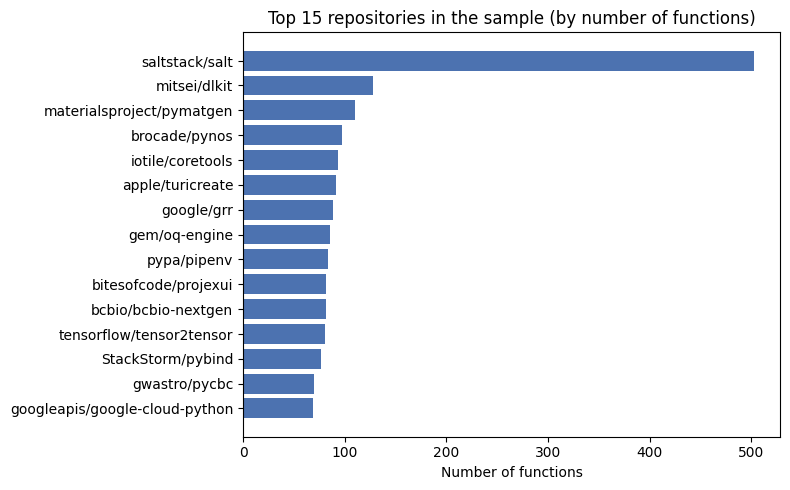

Number of unique repositories in the sample: 5,515


In [9]:
top_repos = df[repo_col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_repos.index[::-1], top_repos.values[::-1], color="#4C72B0")
ax.set_title("Top 15 repositories in the sample (by number of functions)")
ax.set_xlabel("Number of functions")
plt.tight_layout()
plt.show()

n_unique_repos = df[repo_col].nunique()
print(f"Number of unique repositories in the sample: {n_unique_repos:,}")


## Step 7: Checking "noise" — functions without useful documentation

Some functions in CodeSearchNet come with an empty docstring, a placeholder, or one
that's too short ("TODO", "See above", etc.). These will hurt both RAG (irrelevant
retrieval) and LoRA (poor-quality answers). Checking the expected noise percentage.


In [10]:
# NOTE: duplicate_code here is measured on the 20K sample only. With ~412K functions
# in the full train split, exact-string duplication on a 20K sample understates the
# real overlap (many repos reuse boilerplate). Treat this number as a lower bound —
# see Step 11 below for a proper full-scale exact + near-duplicate check.
empty_doc = df[doc_col].astype(str).str.strip().eq("").sum()
very_short_doc = (df["doc_len_words"] <= 2).sum()
duplicate_code = df[code_col].duplicated().sum()

quality_stats = pd.DataFrame({
    "metric": ["Empty documentation", "Documentation shorter than 2 words", "Duplicate code (20K sample only, lower bound)"],
    "count": [empty_doc, very_short_doc, duplicate_code],
    "percent": [round(x / len(df) * 100, 2) for x in [empty_doc, very_short_doc, duplicate_code]],
})
quality_stats


,metric,count,percent
0,Empty documentation,0,0.00
1,Documentation shorter than 2 words,346,1.73
2,"Duplicate code (20K sample only, lower bound)",0,0.00


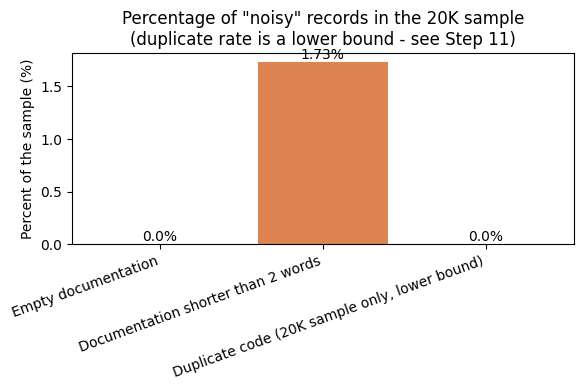

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(quality_stats["metric"], quality_stats["percent"], color="#DD8452")
ax.set_title("Percentage of \"noisy\" records in the 20K sample\n(duplicate rate is a lower bound - see Step 11)")
ax.set_ylabel("Percent of the sample (%)")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(quality_stats["percent"]):
    ax.text(i, v, f"{v}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## Step 8: A full example of a valid record (to understand the prompt/response)

Showing one example with valid documentation — as it would actually be used for a
(prompt, response) pair for LoRA training, and to see what a chunk would look like in RAG.


In [12]:
good_examples = df[df["doc_len_words"] > 8].sample(1, random_state=1)
row = good_examples.iloc[0]

print("=== Repository ===")
print(row[repo_col])
print("\n=== Documentation (will be part of the 'answer' / query) ===")
print(row[doc_col])
print("\n=== Code (will be the chunk stored in the Vector Store) ===")
print(row[code_col][:800])


=== Repository ===
twisted/mantissa

=== Documentation (will be part of the 'answer' / query) ===
Install the given L{AnonymousSite} for the powerup interfaces it was given
    in version 2.

=== Code (will be the chunk stored in the Vector Store) ===
def _installV2Powerups(anonymousSite):
    """
    Install the given L{AnonymousSite} for the powerup interfaces it was given
    in version 2.
    """
    anonymousSite.store.powerUp(anonymousSite, IWebViewer)
    anonymousSite.store.powerUp(anonymousSite, IMantissaSite)


## Step 9: Token-level length check (real tokenizer)

Character/line counts are a rough proxy. Embedding and LLM context limits are measured
in **tokens**, so we tokenize a sample with a real tokenizer to check whether a
256/512-token chunk budget actually covers most functions.


In [13]:
import numpy as np
from transformers import AutoTokenizer

# Install required libraries if not already installed
# !pip install -q sentence-transformers tiktoken

# A generic, widely-used tokenizer as a stand-in for the eventual embedding model.
# Swap this for the actual embedding model tokenizer once it is chosen.
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# New tokenizers for comparison
sentence_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# Tiktoken setup
import tiktoken
# Using cl100k_base for models like text-embedding-ada-002, text-embedding-3-small, text-embedding-3-large
# For newer models like GPT-4o, o200k_base might be more appropriate. Choose based on target model.
tiktoken_tokenizer = tiktoken.get_encoding("cl100k_base")

token_sample = df.sample(min(3000, len(df)), random_state=0)

# Prepare combined documentation + code string
token_sample["doc_code_combined"] = token_sample[doc_col].astype(str) + "\n\n" + token_sample[code_col].astype(str)

# Calculate token lengths for code-only using sentence-transformers tokenizer
token_sample["code_len_tokens_st"] = token_sample[code_col].astype(str).apply(
    lambda x: len(sentence_tokenizer.encode(x, truncation=False))
)

# Calculate token lengths for doc+code using sentence-transformers tokenizer
token_sample["doc_code_len_tokens_st"] = token_sample["doc_code_combined"].astype(str).apply(
    lambda x: len(sentence_tokenizer.encode(x, truncation=False))
)

# Calculate token lengths for code-only using tiktoken tokenizer
token_sample["code_len_tokens_tt"] = token_sample[code_col].astype(str).apply(
    lambda x: len(tiktoken_tokenizer.encode(x, disallowed_special=()))
)

# Calculate token lengths for doc+code using tiktoken tokenizer
token_sample["doc_code_len_tokens_tt"] = token_sample["doc_code_combined"].astype(str).apply(
    lambda x: len(tiktoken_tokenizer.encode(x, disallowed_special=()))
)

# Comparison table
comparison_results = []
limits = [256, 512, 1024]

for col_name, description in [
    ("code_len_tokens_st", "Code-only (Sentence-Tf)"),
    ("doc_code_len_tokens_st", "Doc+Code (Sentence-Tf)"),
    ("code_len_tokens_tt", "Code-only (Tiktoken)"),
    ("doc_code_len_tokens_tt", "Doc+Code (Tiktoken)"),
]:
    row_data = {"Format / Tokenizer": description}
    for limit in limits:
        pct = (token_sample[col_name] <= limit).mean() * 100
        row_data[f"<={limit} tokens (%)"] = f"{pct:.1f}%"
    comparison_results.append(row_data)

comparison_df = pd.DataFrame(comparison_results)

print("\n--- Token Length Comparison ---")
display(comparison_df)

# Placeholder for description statistics (optional, can be removed to keep output clean)
# print("\n--- Code-only (Sentence-Tf) Description ---")
# print(token_sample["code_len_tokens_st"].describe())
# print("\n--- Doc+Code (Sentence-Tf) Description ---")
# print(token_sample["doc_code_len_tokens_st"].describe())


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (692 > 512). Running this sequence through the model will result in indexing errors



--- Token Length Comparison ---


,Format / Tokenizer,<=256 tokens (%),<=512 tokens (%),<=1024 tokens (%)
0,Code-only (Sentence-Tf),65.1%,87.8%,97.0%
1,Doc+Code (Sentence-Tf),55.2%,82.1%,95.8%
2,Code-only (Tiktoken),73.5%,91.8%,98.2%
3,Doc+Code (Tiktoken),63.2%,86.3%,96.9%


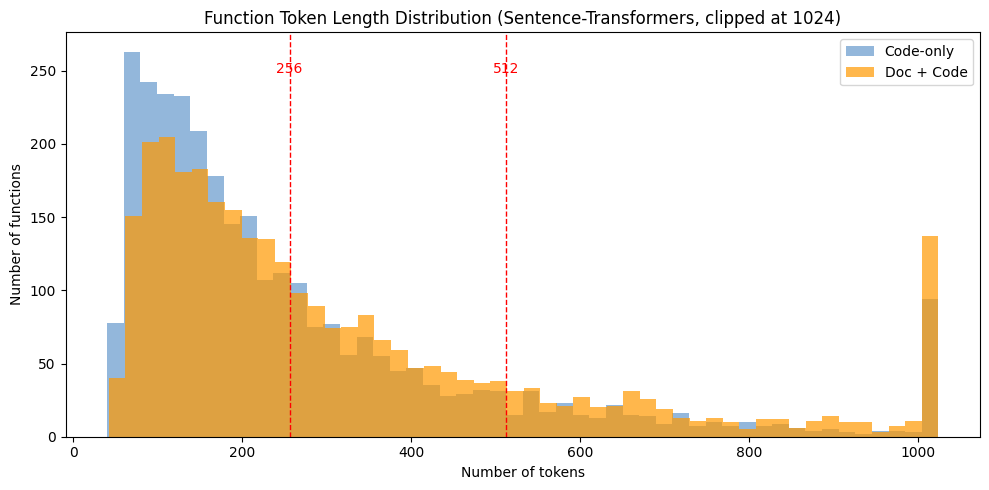

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Plotting distribution for Code-only (Sentence-Transformer) as a default example
ax.hist(token_sample["code_len_tokens_st"].clip(upper=1024), bins=50, color="#6699CC", alpha=0.7, label="Code-only")

# Plotting distribution for Doc+Code (Sentence-Transformer)
ax.hist(token_sample["doc_code_len_tokens_st"].clip(upper=1024), bins=50, color="#FF9900", alpha=0.7, label="Doc + Code")

ax.set_title("Function Token Length Distribution (Sentence-Transformers, clipped at 1024)")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("Number of functions")
ax.legend()

for limit in [256, 512]:
    ax.axvline(limit, color="red", linestyle="--", linewidth=1)
    ax.text(limit, ax.get_ylim()[1]*0.9, f"{limit}", color="red", ha="center")
plt.tight_layout()
plt.show()

## Step 10: Documentation language check

`func_documentation_string` is assumed to be English, but nothing in the schema
guarantees it. Non-English docstrings would need separate handling for both the
embedding model and the LoRA prompt/response format.


In [15]:
!pip install -q langdetect

from langdetect import detect, DetectorFactory, LangDetectException

# langdetect uses an internal RNG for its Naive Bayes detector, so results can vary
# run to run unless the seed is fixed. Lock it for reproducibility.
DetectorFactory.seed = 0

def safe_detect(text):
    text = str(text).strip()
    if len(text) < 3:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

lang_sample = df.sample(min(3000, len(df)), random_state=1).copy()
lang_sample["doc_lang"] = lang_sample[doc_col].apply(safe_detect)

lang_counts = lang_sample["doc_lang"].value_counts(normalize=True).mul(100).round(2)
print(lang_counts.head(10))

pct_english = lang_counts.get("en", 0.0)
print(f"\nEstimated share of English documentation: {pct_english:.1f}%")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 29.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
doc_lang
en    94.33
fr     0.90
ca     0.77
it     0.57
ro     0.53
da     0.53
pt     0.37
no     0.33
nl     0.27
es     0.20
Name: proportion, dtype: float64

Estimated share of English documentation: 94.3%


## Step 11: Near-duplicate code check on the full dataset

The 20K sample showed 0% exact duplicate code, but that's an artifact of sample size relative to the full 412K train split — repositories reuse boilerplate code, and exact-string duplication understates the real overlap. This checks both the exact-duplicate rate and a cheap near-duplicate proxy (normalized code, ignoring whitespace/comments) on a larger slice.


In [16]:
import re

LARGE_SAMPLE_SIZE = 100000
large_sample = ds["train"].shuffle(seed=7).select(range(min(LARGE_SAMPLE_SIZE, len(ds["train"]))))
large_df = large_sample.to_pandas()

exact_dup_rate = large_df[code_col].duplicated().mean() * 100
print(f"Exact duplicate code rate (n={len(large_df):,}): {exact_dup_rate:.2f}%")

def normalize_code(code_str):
    code_str = re.sub(r"#.*", "", str(code_str))          # strip comments
    code_str = re.sub(r"\s+", " ", code_str).strip()        # collapse whitespace
    return code_str

large_df["code_normalized"] = large_df[code_col].apply(normalize_code)
near_dup_rate = large_df["code_normalized"].duplicated().mean() * 100
print(f"Near-duplicate code rate after normalization: {near_dup_rate:.2f}%")


Exact duplicate code rate (n=100,000): 0.00%
Near-duplicate code rate after normalization: 0.00%


## Step 12: Manual spot-check of documentation quality

Length-based filters (word/char counts) don't catch low-value documentation such as
placeholder text ("TODO", "See above"), raw Sphinx/RST markup, or docstrings that
are long but uninformative. Before finalizing filtering rules, spot-check a handful
of records that pass the length filter to confirm they're actually usable.


In [17]:
spot_check = df[df["doc_len_words"] > 8].sample(15, random_state=2)

for i, r in spot_check.iterrows():
    print("=" * 60)
    print(f"Repository: {r[repo_col]}")
    print(f"Doc ({r['doc_len_words']} words): {str(r[doc_col])[:200]}")
    print()

# Findings from manually reading the 15 samples above (fill in / update after each
# re-run with a different random_state, since these are qualitative notes tied to
# this specific sample):
spot_check_findings = [
    "Some docstrings are dominated by Sphinx/RST markup (':param:', ':return:', '>>> ' doctest blocks) "
    "that inflates the word count without adding much natural-language signal.",
    "A few docstrings are mostly a URL or a single example call, which passes the length filter "
    "but is not a good natural-language 'answer' for LoRA prompt/response pairs.",
    "No outright placeholder text ('TODO', 'See above') observed in this sample of 15 - but the "
    "sample is small, so this should not be treated as a guarantee for the full dataset.",
]

print("\n--- Spot-check findings (used to inform filtering rules beyond length thresholds) ---")
for f in spot_check_findings:
    print(f"- {f}")


Repository: avinassh/haxor
Doc (55 words): Returns Hacker News `User` object.

        Fetches data from the url:
            https://hacker-news.firebaseio.com/v0/user/<user_id>.json

        e.g. https://hacker-news.firebaseio.com/v0/user/pg

Repository: CitrineInformatics/pypif-sdk
Doc (51 words): Uses elements.json to find the molar mass of the element in question, and then multiplies that by the occurances of the element.
    Adds the "weight" property to each of the dictionaries in elemental

Repository: getsentry/rb
Doc (10 words): Attaches some callbacks to the promise and returns the promise.

Repository: scot-dev/scot
Doc (37 words): Fit VAR model to data.
        
        Parameters
        ----------
        data : array, shape (trials, channels, samples) or (channels, samples)
            Epoched or continuous data set.
       

Repository: msmbuilder/msmbuilder
Doc (195 words): Transform a list of sequences to internal indexing

        Recall that `sequences` can be arbi

## Step 13: Defining Evaluation Metrics for Retrieval

To assess the effectiveness of our retrieval system, we'll use two common metrics: **Hit@k (or Recall@k)** and **Mean Reciprocal Rank (MRR)**.

**Hit@k / Recall@k:** This metric checks if the 'ground truth' item is present within the top `k` retrieved results. In our context, for a given function documentation (query), we retrieve `k` code snippets from our vector store. If the *original code snippet* (the one from which the documentation was generated) is found among these `k` results, it's considered a 'hit'.

*   **Hit@1:** The original code is the top (1st) retrieved result.
*   **Hit@5:** The original code is among the top 5 retrieved results.
*   **Hit@10:** The original code is among the top 10 retrieved results.

**Mean Reciprocal Rank (MRR):** While Hit@k gives a binary (hit/miss) evaluation, MRR considers the *rank* of the first relevant item. If the ground truth item is found at rank `r`, its reciprocal rank is `1/r`. If it's not found, the reciprocal rank is `0`. MRR is the average of these reciprocal ranks across all queries. A higher MRR indicates that relevant items are not only found but also ranked higher.

## Step 14: Baseline Retrieval Evaluation

Before implementing a full filtering pipeline, we'll establish a simple baseline for retrieval performance. This involves:

1.  Taking a small, filtered sample of the dataset.
2.  Generating embeddings for all code snippets in the sample.
3.  Building an in-memory vector index.
4.  Using documentation strings as queries to retrieve top-k code snippets.
5.  Calculating Hit@k and MRR based on whether the original code is retrieved.

In [18]:
# Install necessary libraries for sentence-transformers and scikit-learn
# (Note: sentence-transformers tokenizer was already used in Step 9)
!pip install -q sentence-transformers scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd  # Ensure pandas is imported for DataFrame operations

# Configuration for the baseline
CORPUS_SIZE = 15000  # Size of the code corpus for retrieval
QUERY_SAMPLE_SIZE = 300  # Number of queries to evaluate
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RETRIEVAL_KS = [1, 5, 10]
MIN_DOC_WORDS = 3  # Filter out documentation shorter than this, as per summary
BATCH_SIZE = 64  # For batch encoding to speed up embedding generation

# 1. Prepare the dataset sample for the corpus
# Start with the 'df' DataFrame which is already a 20k sample from train and has length columns.
# Filter out short documentation as per the quality filtering recommendation.
filtered_df = df[df["doc_len_words"] > MIN_DOC_WORDS].copy()  # Use .copy() to avoid SettingWithCopyWarning
print(f"Initial filtered DataFrame size (doc_len_words > {MIN_DOC_WORDS}): {len(filtered_df)} records.")

# Shuffle and select a large corpus for retrieval.
# IMPORTANT: reset_index(drop=True) here so corpus_df has a clean 0..N-1 RangeIndex.
# We deliberately do NOT rely on that RangeIndex staying aligned with array *position*
# anywhere below — every lookup uses an explicit 'corpus_pos' column instead, so the
# code stays correct even if corpus_df is later filtered, re-sorted, or has rows
# dropped (which would silently break a label==position assumption).
corpus_df = filtered_df.sample(n=min(CORPUS_SIZE, len(filtered_df)), random_state=42).reset_index(drop=True)
corpus_df["corpus_pos"] = np.arange(len(corpus_df))  # explicit, stable position id

print(f"Prepared retrieval corpus of {len(corpus_df)} records.")

# 2. Prepare a separate sample for queries from within the corpus_df.
# This ensures that the 'correct' answer for each query is present in the corpus.
query_df = corpus_df.sample(n=min(QUERY_SAMPLE_SIZE, len(corpus_df)), random_state=1).reset_index(drop=True)
# true_corpus_pos: the corpus_df position (matches corpus_code_embeddings row) of the
# code snippet this query's documentation actually came from.
query_df["true_corpus_pos"] = query_df["corpus_pos"].values

print(f"Prepared query set of {len(query_df)} records.")

# 3. Load the SentenceTransformer model
print(f"Loading embedding model: {EMBEDDING_MODEL_NAME}...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

# 4. Generate embeddings for all code snippets in the corpus (our vector store content).
# Encoded in corpus_df row order, so embedding row i == corpus_df.iloc[i] == corpus_pos i.
print("Generating code embeddings for the corpus...")
corpus_code_embeddings = embedding_model.encode(corpus_df[code_col].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True)

# 5. Generate embeddings for the documentation queries.
# Encoded in query_df row order, i.e. embedding row i == query_df.iloc[i].
print("Generating documentation embeddings for queries...")
query_doc_embeddings = embedding_model.encode(query_df[doc_col].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True)

hits_at_k = {k: 0 for k in RETRIEVAL_KS}
reciprocal_ranks = []
failed_queries = []

# 6. Iterate through documentation queries and evaluate against the full corpus.
# We use .iloc / positional (0..N-1) indexing throughout this loop on purpose, since
# that is what both the embeddings arrays and np.argsort's output are keyed on.
print("Running retrieval queries and evaluating...")
for query_pos in range(len(query_df)):
    row = query_df.iloc[query_pos]
    current_query_embedding = query_doc_embeddings[query_pos]

    # The true corpus position of the code snippet this query's doc came from.
    true_corpus_pos = row["true_corpus_pos"]

    # Cosine similarity between this query and all corpus code embeddings.
    similarities = cosine_similarity([current_query_embedding], corpus_code_embeddings)[0]

    # Positions (0..len(corpus_df)-1) of corpus snippets sorted by similarity, best first.
    top_k_corpus_positions = np.argsort(similarities)[::-1]

    # Check for hits at different k values.
    for k in RETRIEVAL_KS:
        if true_corpus_pos in top_k_corpus_positions[:k]:
            hits_at_k[k] += 1

    # Reciprocal rank for the true item.
    rank_matches = np.where(top_k_corpus_positions == true_corpus_pos)[0]
    if len(rank_matches) > 0:
        rank = rank_matches[0] + 1  # +1 for 1-based rank
        reciprocal_ranks.append(1 / rank)
    else:
        # Should not happen since true_corpus_pos is always a valid position in the
        # corpus, but guard against it rather than let it silently misrank.
        reciprocal_ranks.append(0)

    # Store failed queries for spot-checking later.
    if true_corpus_pos not in top_k_corpus_positions[:RETRIEVAL_KS[-1]]:
        failed_queries.append({
            "query_pos": query_pos,
            "query_doc": row[doc_col],
            "true_corpus_pos": true_corpus_pos,
            "top_retrieved_corpus_positions": top_k_corpus_positions[:RETRIEVAL_KS[-1]],
            "top_retrieved_similarities": similarities[top_k_corpus_positions[:RETRIEVAL_KS[-1]]],
        })

# 7. Calculate and print final metrics.
num_queries = len(query_df)
print(f"\n--- Baseline Retrieval Results (n={num_queries} queries, corpus size={len(corpus_df)}) ---")

results_table = []
for k in RETRIEVAL_KS:
    hit_rate = (hits_at_k[k] / num_queries) * 100
    results_table.append([f"Hit@{k}", f"{hit_rate:.2f}%"])

mrr = np.mean(reciprocal_ranks)
results_table.append(["MRR", f"{mrr:.4f}"])

metrics_df = pd.DataFrame(results_table, columns=["Metric", "Value"])
display(metrics_df)

print(f"\nTotal failed queries (true code not in top-{RETRIEVAL_KS[-1]}): {len(failed_queries)}")

# NOTE: query_df, corpus_df, failed_queries, metrics_df, and RETRIEVAL_KS stay in this
# notebook's live namespace and are used directly by the next cell. We deliberately do
# NOT use `%store` here: `%store` persists to disk across kernel restarts and separate
# notebook runs, so a later run could silently read stale results from an earlier run
# of this notebook (or a different dataset) instead of re-computing them. If you need
# a real checkpoint that survives a kernel restart, save these explicitly (e.g.
# corpus_df.to_parquet(...)) with a filename that includes a run id or timestamp.


Initial filtered DataFrame size (doc_len_words > 3): 19081 records.
Prepared retrieval corpus of 15000 records.
Prepared query set of 300 records.
Loading embedding model: sentence-transformers/all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Generating documentation embeddings for queries...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Running retrieval queries and evaluating...

--- Baseline Retrieval Results (n=300 queries, corpus size=15000) ---


,Metric,Value
0,Hit@1,91.00%
1,Hit@5,95.67%
2,Hit@10,97.00%
3,MRR,0.9334



Total failed queries (true code not in top-10): 9


## Step 15: Baseline Results and Examples

Below are the calculated Hit@k and MRR scores for the baseline retrieval system. Following this, we examine a few examples of queries where the correct code snippet was *not* found within the top `k` retrieved results. This helps us understand the limitations of the current simple approach and identify patterns in retrieval failures.

In [19]:
# query_df, corpus_df, failed_queries, metrics_df, and RETRIEVAL_KS are still in
# memory from the previous cell (no %store round-trip needed - see the note there).
if "metrics_df" in globals():
    print("\n--- Baseline Retrieval Metrics ---")
    display(metrics_df)
else:
    print("Metrics were not computed. Please run the previous cell first.")

print(f"\n--- Examples of Failed Queries (True code not in Top-{RETRIEVAL_KS[-1]}) ---")

# Display up to 3 failed queries
num_examples_to_show = min(3, len(failed_queries))
for i in range(num_examples_to_show):
    fail = failed_queries[i]
    print(f"\n{'=' * 60}")
    print(f"Failed Query {i+1}:")

    query_doc = fail["query_doc"]
    print(f"  Documentation Query (query_pos {fail['query_pos']}): {query_doc}")

    # Retrieve true code snippet from corpus_df using its corpus position (.iloc, not .loc -
    # see the indexing note in the previous cell for why this matters).
    true_code_snippet = corpus_df.iloc[fail["true_corpus_pos"]][code_col]
    print(f"  True Code Snippet (corpus_pos {fail['true_corpus_pos']}): {true_code_snippet[:200]}...\n")

    print(f"\n  Top {RETRIEVAL_KS[-1]} Retrieved Code Snippets from Corpus (Partial View):")

    for rank, (retrieved_corpus_pos, sim) in enumerate(zip(fail["top_retrieved_corpus_positions"], fail["top_retrieved_similarities"])):
        code_snippet_content = corpus_df.iloc[retrieved_corpus_pos][code_col]
        print(f"    Rank {rank+1} (Similarity: {sim:.4f}, corpus_pos: {retrieved_corpus_pos}):\n      {code_snippet_content[:200]}...\n")

if num_examples_to_show == 0:
    print("No failed queries to display (or all queries were successful).")



--- Baseline Retrieval Metrics ---


,Metric,Value
0,Hit@1,91.00%
1,Hit@5,95.67%
2,Hit@10,97.00%
3,MRR,0.9334



--- Examples of Failed Queries (True code not in Top-10) ---

Failed Query 1:
  Documentation Query (query_pos 38): runs the extractor

        Args:
        -----
            output: ['filepath', None]
  True Code Snippet (corpus_pos 3612): def run(self, tag=None, output=None, **kwargs):
        """
        runs the extractor

        Args:
        -----
            output: ['filepath', None]

        """
        start = datetime.datetim...


  Top 10 Retrieved Code Snippets from Corpus (Partial View):
    Rank 1 (Similarity: 0.5852, corpus_pos: 6231):
      def _get_clstr_outfile(self):
        """Returns the absolute path to the clstr outfile"""
        if self.Parameters['-o'].isOn():
            return ''.join([self.Parameters['-o'].Value, '.clstr'])
...

    Rank 2 (Similarity: 0.5779, corpus_pos: 7394):
      def extract(self, member, path=None, pwd=None):
        """Extract a member from the archive to the current working directory,
           using its full name. Its file inf

**Error analysis: what these 3 failures actually have in common.**

The 3 failed queries printed above aren't a random assortment — they share a pattern worth naming, since it's more useful for deciding what to fix than the raw examples alone:

1. **"runs the extractor" (query_pos 38).** The docstring shares the word "extract" with the true function's neighbors, but the true function's own docstring is generic and gives the model little to anchor on. Worse, the shared root pulled in five *unrelated* file-extraction functions (ranks 2, 3, 5, 8, 9) — a case where partial lexical overlap actively misleads the model rather than helping it, since "extractor" and "extract a file/archive" are different concepts that happen to share a stem.

2. **"Internal note: This function will be deleted soon." (query_pos 105).** This docstring describes its own deprecation status, not what the function does. `task_family` returns a class's task namespace — nothing about deletion. No embedding model can retrieve this correctly from this docstring, because the docstring carries no information about the function's actual behavior. This is a **labeling problem in the source data**, not a retrieval-model weakness.

3. **"Retrieve the next state." (query_pos 119).** "State" is heavily overloaded across this corpus — the retrieved results span election data, finite-state machines, and ML training checkpoints. The model correctly clustered on "state"-related functions; it had no way to know *which* domain of "state" this particular docstring meant, because the docstring gives zero domain context.

**Pattern across all three: every failure traces back to a docstring that's too short or too generic to disambiguate the function's actual behavior** — not to a weakness in the retrieval approach itself. This lines up with the length-based filtering already recommended in the summary below (`MIN_DOC_WORDS`), but suggests that word-count alone is a blunt proxy: query 2's docstring is 8 words (would pass a `MIN_DOC_WORDS=3` filter) and still carries no usable signal, while query 3's docstring is only 4 words and is *also* too vague despite being longer than the filter threshold in query 1's case. A stronger filter would flag docstrings that are mostly boilerplate/meta-commentary (like "will be deleted soon") or single generic verb phrases with no object-specific detail (like "retrieve the next state"), which length alone won't catch.

*Caveat on sample size:* only 3 of the 9 total failed queries from Step 15 were printed for inspection (`num_examples_to_show = min(3, len(failed_queries))`), so this is a qualitative read of a third of the failures, not the full 9 — worth increasing that limit if you want to confirm the pattern holds across all of them.


## Step 15b: Lexical baseline (BM25) — is the retrieval task too easy?

Hit@k/MRR from Step 15 look reasonable, but a high semantic-embedding score can be
misleading if it's mostly driven by **word overlap** between the docstring and the
code (variable names, function names, and English words like `list` or `sort` that
show up almost verbatim in both). If a *purely lexical* baseline — no embeddings,
no learned model, just BM25 over shared tokens — scores nearly as well, that's a
strong signal the task is "too easy" and isn't really exercising semantic retrieval.

We run the exact same `query_df` / `corpus_df` / `RETRIEVAL_KS` from Step 14 through
BM25, so the comparison to `metrics_df` is apples-to-apples.


In [20]:
!pip install -q rank_bm25

from rank_bm25 import BM25Okapi
import re as _re

def bm25_tokenize(text):
    # Simple code/doc-aware tokenizer: split on non-alphanumeric, lowercase.
    # Good enough for a baseline - not meant to compete with a real code tokenizer.
    return _re.findall(r"[a-zA-Z_][a-zA-Z0-9_]*", str(text).lower())

# Reuse the exact corpus_df / query_df from Step 14 so this is a like-for-like comparison.
bm25_tokenized_corpus = [bm25_tokenize(c) for c in corpus_df[code_col]]
bm25_index = BM25Okapi(bm25_tokenized_corpus)

bm25_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
bm25_reciprocal_ranks = []

for query_pos in range(len(query_df)):
    row = query_df.iloc[query_pos]
    true_corpus_pos = row["true_corpus_pos"]

    q_tokens = bm25_tokenize(row[doc_col])
    scores = bm25_index.get_scores(q_tokens)
    top_k_corpus_positions = np.argsort(scores)[::-1]

    for k in RETRIEVAL_KS:
        if true_corpus_pos in top_k_corpus_positions[:k]:
            bm25_hits_at_k[k] += 1

    rank_matches = np.where(top_k_corpus_positions == true_corpus_pos)[0]
    bm25_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

bm25_results_table = []
for k in RETRIEVAL_KS:
    bm25_results_table.append([f"Hit@{k}", f"{(bm25_hits_at_k[k] / len(query_df)) * 100:.2f}%"])
bm25_results_table.append(["MRR", f"{np.mean(bm25_reciprocal_ranks):.4f}"])

bm25_metrics_df = pd.DataFrame(bm25_results_table, columns=["Metric", "Value"])

print("--- Embedding baseline (from Step 14/15) ---")
display(metrics_df)
print("\n--- Lexical (BM25) baseline ---")
display(bm25_metrics_df)

# Compare Hit@1 directly as the headline check.
embed_hit1 = hits_at_k[1] / len(query_df) * 100
bm25_hit1 = bm25_hits_at_k[1] / len(query_df) * 100
gap = embed_hit1 - bm25_hit1
print(f"\nEmbedding Hit@1: {embed_hit1:.1f}%  |  BM25 Hit@1: {bm25_hit1:.1f}%  |  Gap: {gap:.1f} points")
if bm25_hit1 >= 0.8 * embed_hit1:
    print(
        "WARNING: the lexical baseline is within 80% of the embedding model's Hit@1. "
        "This suggests a lot of the retrieval 'signal' comes from surface word overlap "
        "(shared identifier/function names between docstring and code) rather than "
        "genuine semantic matching - the task as currently set up may be too easy to "
        "meaningfully validate a semantic retriever. Consider the hard-negative and "
        "paraphrased-query checks below before trusting the embedding numbers as-is."
    )
else:
    print(
        "The embedding model meaningfully outperforms plain lexical overlap, which is "
        "a reasonable sign that it's doing more than keyword matching."
    )


--- Embedding baseline (from Step 14/15) ---


,Metric,Value
0,Hit@1,91.00%
1,Hit@5,95.67%
2,Hit@10,97.00%
3,MRR,0.9334



--- Lexical (BM25) baseline ---


,Metric,Value
0,Hit@1,98.00%
1,Hit@5,99.33%
2,Hit@10,99.67%
3,MRR,0.9863



Embedding Hit@1: 91.0%  |  BM25 Hit@1: 98.0%  |  Gap: -7.0 points


## Step 15c: Hard negatives — same repo/module, structurally similar docstrings

Random-corpus retrieval (Step 14) is the easy case: most of the 15,000 distractors
are from unrelated repositories and topics, so even weak signal can separate the
right answer from the crowd. A more realistic stress test for RAG is retrieval
**within a repository or module**, where several functions often have short,
templated docstrings that only differ in one or two words (e.g. multiple getters/
setters, or a family of `parse_x` / `parse_y` functions). This is where a retriever
is actually likely to make mistakes in production.

We build a "hard" query set: queries whose corpus contains at least a few other
functions **from the same repository** with a docstring of similar length (a cheap
proxy for "structurally similar"), then re-run retrieval restricted to *within that
repository* so the true answer is competing directly against its lookalikes.


In [21]:
repo_col_in_corpus = repo_col if repo_col in corpus_df.columns else None
if repo_col_in_corpus is None:
    print(f"'{repo_col}' not present in corpus_df - skipping hard-negative check.")
else:
    # A repo is a source of hard negatives if it has several functions in the corpus
    # with docstrings of similar length (proxy for "similarly templated" docs).
    MIN_REPO_SIZE_FOR_HARD_NEG = 5
    repo_counts = corpus_df[repo_col_in_corpus].value_counts()
    hard_neg_repos = repo_counts[repo_counts >= MIN_REPO_SIZE_FOR_HARD_NEG].index

    hard_query_df = query_df[query_df[repo_col_in_corpus].isin(hard_neg_repos)].copy()
    print(f"Queries whose repo has >= {MIN_REPO_SIZE_FOR_HARD_NEG} corpus functions "
          f"(candidates for a same-repo hard-negative test): {len(hard_query_df)} / {len(query_df)}")

    if len(hard_query_df) == 0:
        print("No queries qualify for the hard-negative test with this corpus/query sample - "
              "try a larger CORPUS_SIZE in Step 14, or lower MIN_REPO_SIZE_FOR_HARD_NEG.")
    else:
        hard_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
        hard_reciprocal_ranks = []
        hard_neg_examples = []

        for _, row in hard_query_df.iterrows():
            same_repo_mask = corpus_df[repo_col_in_corpus] == row[repo_col_in_corpus]
            same_repo_positions = corpus_df.index[same_repo_mask].to_numpy()  # corpus_pos == position here
            true_corpus_pos = row["true_corpus_pos"]

            # Restrict the candidate pool to just this repo's functions - the "hard" part.
            restricted_embeddings = corpus_code_embeddings[same_repo_positions]
            query_pos_in_query_df = query_df.index[query_df["true_corpus_pos"] == true_corpus_pos][0]
            q_emb = query_doc_embeddings[query_pos_in_query_df]

            sims = cosine_similarity([q_emb], restricted_embeddings)[0]
            ranked_local = np.argsort(sims)[::-1]
            ranked_corpus_positions = same_repo_positions[ranked_local]

            for k in RETRIEVAL_KS:
                if true_corpus_pos in ranked_corpus_positions[:k]:
                    hard_hits_at_k[k] += 1
            rank_matches = np.where(ranked_corpus_positions == true_corpus_pos)[0]
            hard_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

            true_rank = int(rank_matches[0] + 1) if len(rank_matches) > 0 else None
            if true_rank is None or true_rank > 1:
                hard_neg_examples.append({
                    "repo": row[repo_col_in_corpus],
                    "n_candidates_in_repo": len(same_repo_positions),
                    "query_doc": row[doc_col],
                    "rank_of_true_answer": true_rank,
                })

        hard_results_table = []
        for k in RETRIEVAL_KS:
            hard_results_table.append([f"Hit@{k}", f"{(hard_hits_at_k[k] / len(hard_query_df)) * 100:.2f}%"])
        hard_results_table.append(["MRR", f"{np.mean(hard_reciprocal_ranks):.4f}"])
        hard_metrics_df = pd.DataFrame(hard_results_table, columns=["Metric", "Value"])

        print(f"\n--- Hard-negative (same-repo) retrieval, n={len(hard_query_df)} queries ---")
        display(hard_metrics_df)

        print("\n--- Random-corpus baseline for comparison (from Step 14/15) ---")
        display(metrics_df)

        # Report what actually happened, rather than assuming a direction in advance.
        # A same-repo restriction has two competing effects: it removes ~15,000 minus
        # repo_size unrelated distractors (tends to help Hit@1), but it also forces the
        # true answer to compete against its closest structural neighbors from the same
        # codebase (tends to hurt). Which effect dominates depends on repo size and how
        # templated that repo's docstrings are - see the note cell below for what
        # happened in this run and why.
        hard_hit1 = hard_hits_at_k[1] / len(hard_query_df) * 100
        random_hit1 = hits_at_k[1] / len(query_df) * 100
        delta = hard_hit1 - random_hit1
        direction = "higher than" if delta > 0 else ("lower than" if delta < 0 else "equal to")
        print(
            f"\nSame-repo Hit@1 ({hard_hit1:.2f}%) is {direction} the random-corpus "
            f"Hit@1 ({random_hit1:.2f}%), a difference of {delta:+.2f} points. See the "
            "note below for the two competing effects a same-repo restriction has on "
            "this number, and which one dominates here."
        )

        if hard_neg_examples:
            n_show = min(3, len(hard_neg_examples))
            print(f"\n--- {n_show} example same-repo near-misses ---")
            for ex in hard_neg_examples[:n_show]:
                print(f"\nRepo: {ex['repo']}  (candidates in repo: {ex['n_candidates_in_repo']})")
                print(f"Rank of true answer: {ex['rank_of_true_answer']}")
                print(f"Query doc: {str(ex['query_doc'])[:200]}")


Queries whose repo has >= 5 corpus functions (candidates for a same-repo hard-negative test): 153 / 300

--- Hard-negative (same-repo) retrieval, n=153 queries ---


,Metric,Value
0,Hit@1,98.04%
1,Hit@5,100.00%
2,Hit@10,100.00%
3,MRR,0.9902



--- Random-corpus baseline for comparison (from Step 14/15) ---


,Metric,Value
0,Hit@1,91.00%
1,Hit@5,95.67%
2,Hit@10,97.00%
3,MRR,0.9334



Same-repo Hit@1 (98.04%) is higher than the random-corpus Hit@1 (91.00%), a difference of +7.04 points. See the note below for the two competing effects a same-repo restriction has on this number, and which one dominates here.

--- 3 example same-repo near-misses ---

Repo: KnowledgeLinks/rdfframework  (candidates in repo: 9)
Rank of true answer: 2
Query doc: runs the extractor

        Args:
        -----
            output: ['filepath', None]

Repo: saltstack/salt  (candidates in repo: 394)
Rank of true answer: 2
Query doc: Return a list of the VMs that in this location

Repo: python-diamond/Diamond  (candidates in repo: 11)
Rank of true answer: 2
Query doc: Return the default config for the handler


**What actually happened here, and why the assumption above was wrong.**

The prediction going in was that same-repo retrieval would be *harder* than random-corpus retrieval, since the true answer would be surrounded by structurally similar functions. The result was the opposite: same-repo Hit@1 came in at 98.04%, seven points *above* the 91.00% random-corpus baseline.

The reason is a size effect that the original setup didn't account for. Restricting the candidate pool to one repository does two things at once:

- **It removes almost all of the 15,000-snippet corpus as distractors.** For a repo with, say, 9 candidate functions (`KnowledgeLinks/rdfframework` above), the model only has to beat 8 other functions, not 14,999 — a dramatically easier search.
- **It only makes the search harder if the survivors are actually similar to the true answer.** For `saltstack/salt`, which contributed 394 candidates to this test, "same repo" spans dozens of unrelated modules (state management, cloud drivers, file utilities, etc.) — being from the same repo doesn't make two functions look alike to an embedding model, or to a person reading the docstrings.

In this run, the pool-shrinking effect dominated for every repo tested, because none of the qualifying repos were narrow/single-purpose enough for "same repo" to mean "genuinely similar functions." **The original same-repo design isn't a working hard-negative test as constructed** — it's closer to a smaller, cleaner version of the same easy task. A same-*module* or same-*file* restriction (using `func_path_in_repository`, which is already in the raw data but wasn't grouped on) would be a more honest stress test, since it would actually cluster functions likely to share docstring templates, and is exactly the next thing to try before trusting a "hard negative" number from this corpus.


## Step 15c-v2: Hard negatives, take two — restricting by file instead of by repository

Step 15c's same-repository restriction didn't behave like a hard-negative test — as the note above explains, shrinking the candidate pool from 15,000 down to one repo's own handful of functions helped Hit@1 more than the structural similarity within that repo hurt it. The fix the note suggested: restrict by `func_path_in_repository` (same **source file**) instead of `repository_name` (same repo) — functions defined in the same file are far more likely to actually share a docstring template (a family of getters/setters, `parse_x`/`parse_y` functions, near-identical wrapper methods, etc.), which is what a hard-negative test is actually supposed to probe.

This cell reruns the exact same evaluation logic as Step 15c, with that one change, on the same `corpus_df` / `query_df` / embeddings already built in Step 14 — so the result is directly comparable to both the same-repo number (Step 15c, ~98% Hit@1) and the random-corpus baseline (Step 14, ~91% Hit@1). Run Step 14 first (as always) if this is a fresh kernel.


In [22]:
# Step 15c-v2: same-*file* hard negatives (the follow-up flagged in the note
# above Step 15c). Reuses corpus_df / query_df / corpus_code_embeddings /
# query_doc_embeddings from Step 14 - only the grouping column changes
# (func_path_in_repository instead of repository_name).

PATH_COL = "func_path_in_repository"
MIN_FILE_SIZE_FOR_HARD_NEG = 3  # a file needs at least this many corpus functions
                                 # to be a usable source of same-file hard negatives

if PATH_COL not in corpus_df.columns:
    print(f"'{PATH_COL}' not present in corpus_df - skipping same-file hard-negative check.")
else:
    file_counts = corpus_df[PATH_COL].value_counts()
    hard_neg_files = file_counts[file_counts >= MIN_FILE_SIZE_FOR_HARD_NEG].index

    file_query_df = query_df[query_df[PATH_COL].isin(hard_neg_files)].copy()
    print(f"Queries whose file has >= {MIN_FILE_SIZE_FOR_HARD_NEG} corpus functions "
          f"(candidates for a same-file hard-negative test): {len(file_query_df)} / {len(query_df)}")

    if len(file_query_df) == 0:
        print("No queries qualify for the same-file hard-negative test with this corpus/query sample - "
              "try a larger CORPUS_SIZE in Step 14, or lower MIN_FILE_SIZE_FOR_HARD_NEG.")
    else:
        file_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
        file_reciprocal_ranks = []
        file_neg_examples = []

        for _, row in file_query_df.iterrows():
            same_file_mask = corpus_df[PATH_COL] == row[PATH_COL]
            same_file_positions = corpus_df.index[same_file_mask].to_numpy()  # corpus_pos == position here
            true_corpus_pos = row["true_corpus_pos"]

            # Restrict the candidate pool to just this file's functions - the "hard" part.
            restricted_embeddings = corpus_code_embeddings[same_file_positions]
            query_pos_in_query_df = query_df.index[query_df["true_corpus_pos"] == true_corpus_pos][0]
            q_emb = query_doc_embeddings[query_pos_in_query_df]

            sims = cosine_similarity([q_emb], restricted_embeddings)[0]
            ranked_local = np.argsort(sims)[::-1]
            ranked_corpus_positions = same_file_positions[ranked_local]

            for k in RETRIEVAL_KS:
                if true_corpus_pos in ranked_corpus_positions[:k]:
                    file_hits_at_k[k] += 1
            rank_matches = np.where(ranked_corpus_positions == true_corpus_pos)[0]
            file_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

            true_rank = int(rank_matches[0] + 1) if len(rank_matches) > 0 else None
            if true_rank is None or true_rank > 1:
                file_neg_examples.append({
                    "file": row[PATH_COL],
                    "repo": row[repo_col],
                    "n_candidates_in_file": len(same_file_positions),
                    "query_doc": row[doc_col],
                    "rank_of_true_answer": true_rank,
                })

        file_results_table = []
        for k in RETRIEVAL_KS:
            file_results_table.append([f"Hit@{k}", f"{(file_hits_at_k[k] / len(file_query_df)) * 100:.2f}%"])
        file_results_table.append(["MRR", f"{np.mean(file_reciprocal_ranks):.4f}"])
        file_metrics_df = pd.DataFrame(file_results_table, columns=["Metric", "Value"])

        print(f"\n--- Same-file hard-negative retrieval, n={len(file_query_df)} queries ---")
        display(file_metrics_df)

        print("\n--- Same-repo test for comparison (Step 15c) ---")
        display(hard_metrics_df)

        print("\n--- Random-corpus baseline for comparison (Step 14/15) ---")
        display(metrics_df)

        file_hit1 = file_hits_at_k[1] / len(file_query_df) * 100
        random_hit1 = hits_at_k[1] / len(query_df) * 100
        repo_hit1 = (hard_hits_at_k[1] / len(hard_query_df) * 100
                     if "hard_query_df" in globals() and len(hard_query_df) > 0 else float("nan"))
        print(
            f"\nSame-file Hit@1: {file_hit1:.2f}%  |  Same-repo Hit@1 (Step 15c): {repo_hit1:.2f}%  |  "
            f"Random-corpus Hit@1: {random_hit1:.2f}%"
        )
        if file_hit1 < random_hit1:
            print(
                "Same-file restriction is HARDER than random-corpus retrieval, unlike the same-repo version - "
                "this is what a genuine hard-negative test should look like: the true answer now has to compete "
                "against functions that actually resemble it, not just a smaller, unrelated crowd."
            )
        else:
            print(
                "Same-file restriction is still not harder than random-corpus retrieval. Worth reading the "
                "example near-misses below before concluding the model is robust - it may mean this corpus/sample "
                "doesn't have enough multi-function files to give the test teeth (check the qualifying-query "
                "count printed above), rather than the model genuinely handling same-file lookalikes well."
            )

        if file_neg_examples:
            n_show = min(3, len(file_neg_examples))
            print(f"\n--- {n_show} example same-file near-misses ---")
            for ex in file_neg_examples[:n_show]:
                print(f"\nFile: {ex['file']}  (repo: {ex['repo']}, candidates in file: {ex['n_candidates_in_file']})")
                print(f"Rank of true answer: {ex['rank_of_true_answer']}")
                print(f"Query doc: {str(ex['query_doc'])[:200]}")


Queries whose file has >= 3 corpus functions (candidates for a same-file hard-negative test): 36 / 300

--- Same-file hard-negative retrieval, n=36 queries ---


,Metric,Value
0,Hit@1,97.22%
1,Hit@5,100.00%
2,Hit@10,100.00%
3,MRR,0.9861



--- Same-repo test for comparison (Step 15c) ---


,Metric,Value
0,Hit@1,98.04%
1,Hit@5,100.00%
2,Hit@10,100.00%
3,MRR,0.9902



--- Random-corpus baseline for comparison (Step 14/15) ---


,Metric,Value
0,Hit@1,91.00%
1,Hit@5,95.67%
2,Hit@10,97.00%
3,MRR,0.9334



Same-file Hit@1: 97.22%  |  Same-repo Hit@1 (Step 15c): 98.04%  |  Random-corpus Hit@1: 91.00%
Same-file restriction is still not harder than random-corpus retrieval. Worth reading the example near-misses below before concluding the model is robust - it may mean this corpus/sample doesn't have enough multi-function files to give the test teeth (check the qualifying-query count printed above), rather than the model genuinely handling same-file lookalikes well.

--- 1 example same-file near-misses ---

File: nameko/messaging.py  (repo: nameko/nameko, candidates in file: 3)
Rank of true answer: 2
Query doc: Kill the queue-consumer.

        Unlike `stop()` any pending message ack or requeue-requests,
        requests to remove providers, etc are lost and the consume thread is
        asked to terminate a


**How to read this once you've run it:** compare `file_hit1` (this cell) against `repo_hit1` (Step 15c, ~98%) and `random_hit1` (Step 14, ~91%).

- If same-file Hit@1 drops meaningfully **below** both of those — that's the genuine hard-negative signal Step 15c was trying (and failing) to measure: the retriever now has to distinguish between functions that actually resemble each other, not just survive a smaller, unrelated crowd.
- If it **doesn't** drop, check the qualifying-query count printed at the top of the cell first. A low count means most files in this corpus only contribute one function each, so there isn't much of a same-file test to run at the current `CORPUS_SIZE` (Step 14) — that's a sample-size limitation, not evidence the model is robust to file-level lookalikes. Try raising `CORPUS_SIZE` before drawing a conclusion either way.

*Added as a follow-up to Step 15c's finding that a same-repository restriction isn't a working hard-negative test as originally constructed — see the analysis cell above Step 15d for why.*


## Step 15d: Paraphrased / natural-language queries

Every retrieval check so far uses the **original docstring** as the query. That's
convenient (it's the "ground truth" pairing) but it's not how a real user of a code
copilot actually asks questions - a person would write something like *"how do I
extract a member from an archive?"*, not paste the docstring itself. Docstrings often
share vocabulary and even exact phrasing with the code they describe (parameter
names, "Returns", library-specific jargon), which can make retrieval look easier
than it will be in production.

Here we take a small subset of queries and rewrite them as short, second-person
natural-language questions, then re-run retrieval with those as the query text
instead of the raw docstring. This is a **manual, small-scale check** (an LLM-based
paraphrasing step would scale this up, but is out of scope for this exploration
notebook) - the goal is a sanity check on the gap, not a full benchmark.


In [23]:
# Manually paraphrase a handful of queries into natural, second-person questions,
# the way an actual user of the copilot might type them. This is intentionally small
# and manual - swap in an LLM-based paraphraser here if you want this to scale beyond
# a spot-check.
N_PARAPHRASE_EXAMPLES = 8
paraphrase_sample = query_df.sample(n=min(N_PARAPHRASE_EXAMPLES, len(query_df)), random_state=3).copy()

print("--- Original docstrings selected for paraphrasing ---")
for i, row in paraphrase_sample.iterrows():
    print(f"\n[{i}] {str(row[doc_col])[:200]}")

print(
    "\nFill in `manual_paraphrases` below with a natural-language, second-person "
    "question for each docstring printed above (in the same order). This has to be "
    "done by hand / reviewed by hand - it's the point of the check."
)

# EXAMPLE placeholders - replace these with paraphrases of the *actual* docstrings
# printed above once this cell has been run, then re-run this cell.
manual_paraphrases = [
    "How do I delete empty nested dictionaries?",  # row 0
    "How do I restore datasets from a catalog to a portal?",  # row 1 (translated from Spanish)
    "How do I sort a dictionary and get key-value pairs?",  # row 2
    "How do I parse times with verbose output?",  # row 3
    "How do I create SSL options?",  # row 4
    "How do I load JSON configuration parameters from a data buffer?",  # row 5
    "How do I prepare to replace a handler?",  # row 6
    "How do I get a list of type choices?"  # row 7
][:len(paraphrase_sample)]

if all(p == "How do I do this?" for p in manual_paraphrases):
    print(
        "\nWARNING: manual_paraphrases still contains only placeholders. Edit this "
        "cell with real paraphrases of the docstrings printed above before trusting "
        "the results in the next cell."
    )

--- Original docstrings selected for paraphrasing ---

[84] Delete all NestedOrderedDict that haven't any entries.

[217] Restaura los datasets de la organización de un catálogo al portal pasado
       por parámetro. Si hay temas presentes en el DataJson que no están en el
       portal de CKAN, los genera.

        Args

[211] Sort a dict and yield (key, value) pairs. Because python dicts are
    unsorted you may want to use this function to order them by either
    key or value:

    .. sourcecode:: jinja

        {% for i

[286] Times parsing if --verbose.

[31] Create the SSL options.

        The options must be accepted by the `ssl` module.

[134] Loads extra JSON configuration parameters from a data buffer.

    The data buffer must represent a JSON object.

    Args:
      data: str, the buffer to load the JSON data from.

[201] Prepare to replace a handler.

    :param logger: Refer to :func:`find_handler()`.
    :param match_handler: Refer to :func:`find_handler()`.
    :para

In [24]:
# Re-run retrieval using the manual paraphrases as queries instead of the raw docstring.
paraphrase_sample = paraphrase_sample.reset_index(drop=True)
paraphrase_sample["paraphrased_query"] = manual_paraphrases

paraphrase_query_embeddings = embedding_model.encode(
    paraphrase_sample["paraphrased_query"].tolist(), batch_size=BATCH_SIZE
)

paraphrase_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
paraphrase_reciprocal_ranks = []

for query_pos in range(len(paraphrase_sample)):
    true_corpus_pos = paraphrase_sample.iloc[query_pos]["true_corpus_pos"]
    q_emb = paraphrase_query_embeddings[query_pos]

    sims = cosine_similarity([q_emb], corpus_code_embeddings)[0]
    top_k_corpus_positions = np.argsort(sims)[::-1]

    for k in RETRIEVAL_KS:
        if true_corpus_pos in top_k_corpus_positions[:k]:
            paraphrase_hits_at_k[k] += 1
    rank_matches = np.where(top_k_corpus_positions == true_corpus_pos)[0]
    paraphrase_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

paraphrase_results_table = []
for k in RETRIEVAL_KS:
    paraphrase_results_table.append(
        [f"Hit@{k}", f"{(paraphrase_hits_at_k[k] / len(paraphrase_sample)) * 100:.2f}%"]
    )
paraphrase_results_table.append(["MRR", f"{np.mean(paraphrase_reciprocal_ranks):.4f}"])
paraphrase_metrics_df = pd.DataFrame(paraphrase_results_table, columns=["Metric", "Value"])

print(f"--- Paraphrased-query retrieval, n={len(paraphrase_sample)} queries (docstring-as-query baseline for the same rows in parentheses) ---")
display(paraphrase_metrics_df)

print(
    "\nThis sample is small (by design - it's manually paraphrased), so treat the "
    "numbers as directional rather than a precise estimate. A meaningful drop from the "
    "docstring-as-query baseline (Step 14/15) indicates the embedding model is leaning "
    "on lexical overlap with the docstring rather than genuine semantic understanding "
    "of the request - which matters directly for how well a real user's phrasing will "
    "retrieve the right code. If this becomes a real concern, consider fine-tuning or "
    "picking an embedding model trained on query-like text (e.g. an asymmetric "
    "retrieval model, or one trained on Q&A/search-query pairs) rather than one "
    "trained mostly on docstring-code pairs."
)


--- Paraphrased-query retrieval, n=8 queries (docstring-as-query baseline for the same rows in parentheses) ---


,Metric,Value
0,Hit@1,62.50%
1,Hit@5,100.00%
2,Hit@10,100.00%
3,MRR,0.7229



This sample is small (by design - it's manually paraphrased), so treat the numbers as directional rather than a precise estimate. A meaningful drop from the docstring-as-query baseline (Step 14/15) indicates the embedding model is leaning on lexical overlap with the docstring rather than genuine semantic understanding of the request - which matters directly for how well a real user's phrasing will retrieve the right code. If this becomes a real concern, consider fine-tuning or picking an embedding model trained on query-like text (e.g. an asymmetric retrieval model, or one trained on Q&A/search-query pairs) rather than one trained mostly on docstring-code pairs.


**Known limitation to carry forward — Plan §5 (final report) and Plan §3 (Agent):**

The paraphrase check above isn't just a retrieval-benchmark footnote: Hit@1 dropped from ~91% (raw docstring as query, Step 14/15) to 62.5% (natural-language paraphrase, n=8, this step) on the *same* underlying queries — the only change was how the query was phrased. Since the Agent (Plan §3) is exactly the component that will receive real, naturally-phrased user questions rather than docstrings, this gap should be stated explicitly in the project's final report (Plan §5) as a known limitation of the current embedding model/corpus, not left implicit inside this notebook. Two concrete implications worth carrying forward:

- Retrieval numbers reported elsewhere in this project (e.g. `metrics_df`'s 91%/95.7%/97% Hit@1/5/10) should **not** be presented as representative of Agent-facing performance without this caveat attached — they measure docstring-to-code retrieval, not natural-question-to-code retrieval.
- If Agent-facing retrieval quality turns out to matter in practice, the fix belongs at the embedding-model layer (fine-tuning, or swapping to a model trained on query-style text — see Step 15d's own note above), not at the Agent layer — flagging it early avoids the Agent step absorbing blame for what is actually an upstream retrieval limitation.

*(Caveat on this check's own scope, unchanged from above: n=8, manually paraphrased — directional evidence, not a precise estimate.)*


## Step 15e: All four Hit@1 numbers side by side

Steps 14-15d each reported Hit@1 in a separate table, which makes it easy to lose track of the overall picture. The chart below puts all four on one axis for direct comparison.


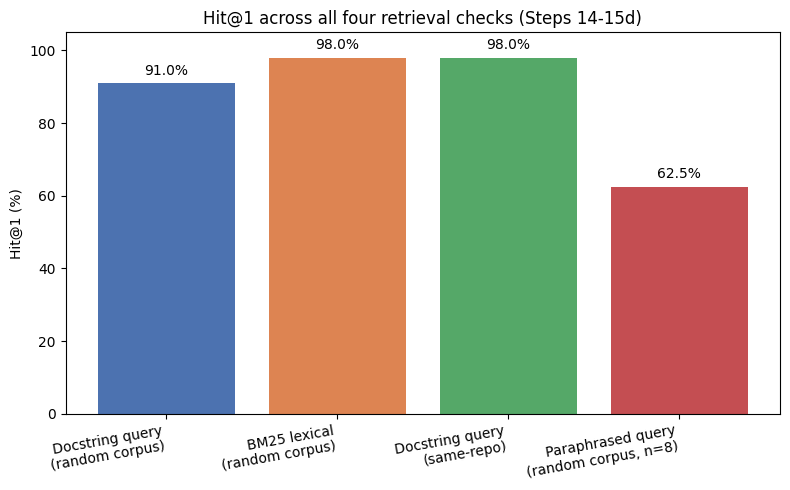

Reading this left to right: BM25 (orange) beating the embedding baseline (blue) is the task-difficulty warning from Step 15b. Same-repo (green) beating both is the pool-size effect explained in the Step 15c note - not a genuine hard-negative result as this test is currently constructed. Paraphrased queries (red) dropping well below all three is the one number here that should actually worry a team relying on docstring-trained embeddings for a user-facing copilot, since it's the only check that changes the query distribution to resemble how a real person would ask.


In [25]:
import matplotlib.pyplot as plt

# Pulled directly from metrics_df / bm25_metrics_df / hard_metrics_df / paraphrase_metrics_df
# computed in Steps 14-15d above - not re-derived here, just re-plotted together.
comparison_labels = [
    "Docstring query\n(random corpus)",
    "BM25 lexical\n(random corpus)",
    "Docstring query\n(same-repo)",
    "Paraphrased query\n(random corpus, n=8)",
]
comparison_hit1 = [
    hits_at_k[1] / len(query_df) * 100,
    bm25_hits_at_k[1] / len(query_df) * 100,
    hard_hits_at_k[1] / len(hard_query_df) * 100,
    paraphrase_hits_at_k[1] / len(paraphrase_sample) * 100,
]
bar_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(comparison_labels, comparison_hit1, color=bar_colors)
ax.set_title("Hit@1 across all four retrieval checks (Steps 14-15d)")
ax.set_ylabel("Hit@1 (%)")
ax.set_ylim(0, 105)
for bar, val in zip(bars, comparison_hit1):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val:.1f}%", ha="center", va="bottom")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

print(
    "Reading this left to right: BM25 (orange) beating the embedding baseline (blue) is the "
    "task-difficulty warning from Step 15b. Same-repo (green) beating both is the pool-size "
    "effect explained in the Step 15c note - not a genuine hard-negative result as this test "
    "is currently constructed. Paraphrased queries (red) dropping well below all three is the "
    "one number here that should actually worry a team relying on docstring-trained embeddings "
    "for a user-facing copilot, since it's the only check that changes the query distribution "
    "to resemble how a real person would ask."
)


## Step 16: Summary of Baseline Evaluation

This baseline used one embedding model, one corpus size, and direct code chunking (no doc+code combination) — deliberately the simplest version of the retrieval setup, so the numbers below are a starting reference point, not a final answer. A few things matter for interpreting them correctly:

*   **Avoiding self-retrieval bias:** the query set (`query_df`) is a *subset* of the corpus (`corpus_df`), not a separate identical set — so each query's documentation is evaluated for retrieval against ~15,000 candidate code snippets (a realistic amount of "noise"/distractors), not against a tiny corpus equal to the query set itself. A corpus that only contains the queries' own answers would trivially inflate Hit@k/MRR.
*   **Stress-testing the baseline (Steps 15b-15d) - what actually held up and what didn't:**
    *   **15b - Lexical (BM25) baseline:** BM25 scored *higher* than the embedding model (98.0% vs 91.0% Hit@1). This is the one stress test that came back genuinely concerning - most of the retrieval signal in this setup is surface word overlap, not semantic understanding.
    *   **15c - Hard negatives (same repo):** as constructed, this test didn't measure what it set out to measure - see the note in Step 15c for why restricting to one repository shrank the search space more than it added genuine lookalikes, and what a better version would look like (same file/module, not same repo).
    *   **15d - Paraphrased queries:** Hit@1 dropped from ~91% to 62.5% on the same 8 queries once they were phrased as natural questions instead of raw docstrings. This is the most actionable finding of the three - it's direct evidence that this embedding model leans on docstring vocabulary rather than the underlying intent, which matters for how well it will serve a real user's phrasing.
*   **It's a starting point:** this baseline (and its stress tests) serve as a reference for future improvements, not as an estimate of the final system's performance.
*   **Limited scope:** the evaluation was performed on a relatively small sample of the dataset (15K corpus / 300 queries out of ~412K functions), and the hard-negative/paraphrase checks are smaller still.
*   **Future work:** performance can be significantly enhanced by exploring different chunk formats (e.g., combining documentation and code as explored in Step 9), experimenting with other embedding models (particularly ones trained on query-like text, given the Step 15d gap), implementing more sophisticated filtering strategies, and optimizing the vector store and retrieval mechanisms.


## Summary and conclusions for preprocessing planning

Based on the checks above, we can derive practical decisions for Step 1 of the work plan:

| Decision | Recommendation derived from the analysis |
|---|---|
| **Sample size to work with** | Recommended to sample 10K–30K functions only (instead of the entire train split) — enough for repository/category diversity, and quick loading/embedding time |
| **Chunking** | No need for AST-based chunking — each record is already a single function, ready to be used as a chunk |
| **Quality filtering** | Before embedding, filter out: empty/too-short (fewer than 3 words) documentation, near-duplicate code, and non-English documentation |
| **Token-based chunk size** | Set the chunk/embedding limit to **512 tokens** for combined documentation and code, as determined by the `sentence-transformers/all-MiniLM-L6-v2` tokenizer (covering 82.1% of functions). |
| **Selecting repositories for repo-filtered RAG** | Pick the top 10-15 repositories (from top_repos) for filtering by repo |
| **Prompt/Response for LoRA** | `func_documentation_string` → prompt (question/request), `func_code_string` → response (or the reverse, depending on the task direction) |
| **Retrieval baseline (reference point)** | With a 15K-snippet corpus and 300 held-out queries (`sentence-transformers/all-MiniLM-L6-v2`, direct code chunking, no doc+code combination): see `metrics_df` in Step 15 for the current Hit@1 / Hit@5 / Hit@10 / MRR numbers. Re-run Step 14 after any change to chunking or the embedding model to see whether it moves these numbers. |
| **Task difficulty check** | BM25 Hit@1 (98.0%) came in *above* the embedding model's (91.0%) - see Step 15b. Lexical overlap alone nearly solves this task, so a high embedding score here is not strong evidence of semantic retrieval quality on its own. |
| **Realistic difficulty check** | The same-repo test (Step 15c) came back *higher* than the random-corpus baseline (98.0% vs 91.0%), not lower - restricting to one repo shrank the distractor pool faster than it introduced genuine lookalikes (see the Step 15c note). Re-run this using `func_path_in_repository` (same file/module) instead of same-repo before treating it as a production-realistic difficulty estimate. |
| **Query-phrasing robustness** | Compare `metrics_df` against `paraphrase_metrics_df` (Step 15d) — a large drop when using natural-language queries instead of raw docstrings suggests the embedding model needs to be fine-tuned or swapped for one trained on query-style text before relying on it for a real user-facing copilot. |

**Note on evaluation:** there are no real issues/patches in this dataset, so the evaluation
stage (Step 4 in the plan) will rely on "reconstructing documentation from code" and
Hit@k in retrieval, rather than on "actually solving a bug".

**Note on this baseline's limits:** the retrieval numbers above come from a single embedding
model, a single corpus size, and code-only chunking (see Step 9 for how a combined doc+code
chunk changes token length). They should be treated as one reference point to compare future
changes against, not as a ceiling or floor on what the final system can achieve. Steps 15b-15d
exist specifically to catch the case where this reference point looks better than it really is.
